In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# --- FASE 1: CARREGAMENTO DOS DADOS BLINDADOS ---
print("A carregar os tensores (com Data Augmentation aplicado no Treino)...")
tensor_X_train = torch.load('../data/tensor_X_train.pt')
tensor_y_train = torch.load('../data/tensor_y_train.pt')

# Batch Size de 128 é o "Ponto Doce" para estabilizar o BatchNorm1d em séries temporais
BATCH_SIZE = 128
train_loader = DataLoader(TensorDataset(tensor_X_train, tensor_y_train), batch_size=BATCH_SIZE, shuffle=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Motor de Processamento: {DEVICE.upper()}")

# --- FASE 2: ARQUITETURA DEFINITIVA (CNN 1D + BATCH NORM) ---
class KeyGuardSiamese(nn.Module):
    def __init__(self):
        super(KeyGuardSiamese, self).__init__()

        # O Extrator de Características (Filtros Convolucionais)
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1),
            nn.BatchNorm1d(16), # <-- CRUCIAL: Estabiliza a variação introduzida pelo ruído sintético
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 3, padding=1),
            nn.BatchNorm1d(32), # <-- CRUCIAL: Mantém a média e a variância alinhadas nas camadas profundas
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # A Camada de Projeção (Gera a "Assinatura" geométrica final)
        self.fc = nn.Sequential(
            nn.Linear(160, 64),
            nn.ReLU(),
            # Usamos 100% dos neurónios, pois o BatchNorm e o Data Augmentation já previnem o Overfitting
            nn.Linear(64, 16)
        )

    def forward_once(self, x):
        x = self.cnn(x)
        x = x.view(x.size()[0], -1) # Flatten (Achatamento)
        return self.fc(x)

    def forward(self, input1, input2):
        # A magia da Rede Siamesa: Passar os dois inputs pela mesma topologia
        return self.forward_once(input1), self.forward_once(input2)

modelo = KeyGuardSiamese().to(DEVICE)
print("\n=== FASE 2 CONCLUÍDA ===")
print("Planta da arquitetura instanciada com sucesso!")

A carregar os tensores (com Data Augmentation aplicado no Treino)...
Motor de Processamento: CPU

=== FASE 2 CONCLUÍDA ===
Planta da arquitetura instanciada com sucesso!



Iniciando Treino de Alta Precisão (100 épocas)...
Época 001/100 | Loss: 0.13910 | LR: 0.001000
Época 002/100 | Loss: 0.10417 | LR: 0.001000
Época 003/100 | Loss: 0.09134 | LR: 0.001000
Época 004/100 | Loss: 0.08324 | LR: 0.001000
Época 005/100 | Loss: 0.07739 | LR: 0.001000
Época 006/100 | Loss: 0.07357 | LR: 0.001000
Época 007/100 | Loss: 0.07016 | LR: 0.001000
Época 008/100 | Loss: 0.06651 | LR: 0.001000
Época 009/100 | Loss: 0.06492 | LR: 0.001000
Época 010/100 | Loss: 0.06241 | LR: 0.001000
Época 011/100 | Loss: 0.06087 | LR: 0.001000
Época 012/100 | Loss: 0.05933 | LR: 0.001000
Época 013/100 | Loss: 0.05820 | LR: 0.001000
Época 014/100 | Loss: 0.05666 | LR: 0.001000
Época 015/100 | Loss: 0.05551 | LR: 0.001000
Época 016/100 | Loss: 0.05471 | LR: 0.001000
Época 017/100 | Loss: 0.05439 | LR: 0.001000
Época 018/100 | Loss: 0.05337 | LR: 0.001000
Época 019/100 | Loss: 0.05282 | LR: 0.001000
Época 020/100 | Loss: 0.05171 | LR: 0.001000
Época 021/100 | Loss: 0.05116 | LR: 0.001000
Époc

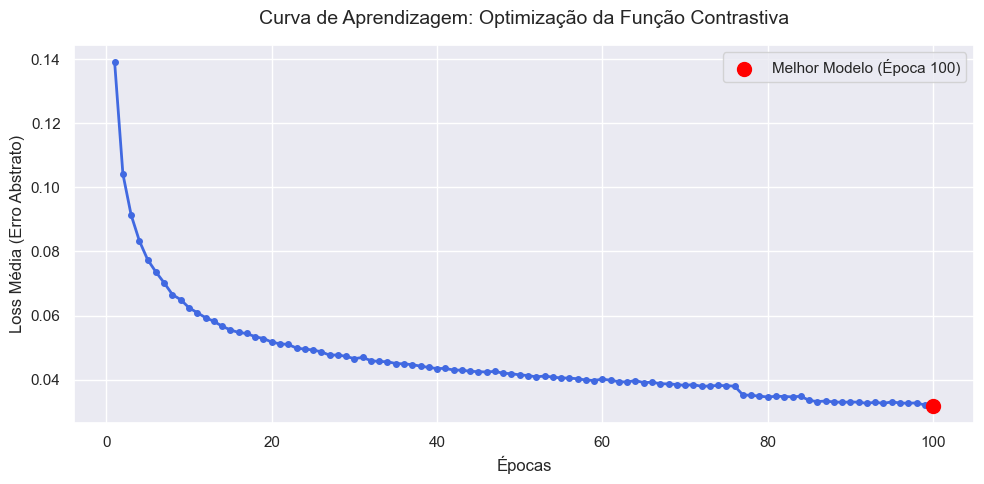

Gráfico gerado. O Notebook 03 está finalizado e blindado para apresentação.


In [2]:
# --- FASE 3: FUNÇÃO DE PERDA E OTIMIZADORES ---
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Calcula a Distância Euclidiana entre as duas assinaturas de 16 dimensões
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)

        # Fórmula: y * d^2 + (1 - y) * max(0, margin - d)^2
        loss_contrastive = torch.mean(
            (label) * torch.pow(euclidean_distance, 2) +
            (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        )
        return loss_contrastive

criterion = ContrastiveLoss(margin=1.0)
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

# Redutor de passos. (Nota: 'verbose=True' removido para evitar avisos de depreciação do PyTorch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# --- FASE 4: TREINO INTENSIVO COM EARLY STOPPING ---
EPOCHS = 100
paciencia_early_stopping = 10
melhor_loss = float('inf')
epocas_sem_melhoria = 0

# Variável nova para rastrear a descida da perda e gerar o gráfico final
historico_loss = []

print(f"\nIniciando Treino de Alta Precisão ({EPOCHS} épocas)...")
modelo.train()

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE).view(-1, 1)

        input1 = X_batch[:, 0, :].unsqueeze(1)
        input2 = X_batch[:, 1, :].unsqueeze(1)

        optimizer.zero_grad()
        output1, output2 = modelo(input1, input2)

        loss = criterion(output1, output2, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    media_loss_epoca = epoch_loss / len(train_loader)
    historico_loss.append(media_loss_epoca)

    # Informa o Scheduler sobre a média atual
    scheduler.step(media_loss_epoca)

    # Captura o Learning Rate atual para exibir no terminal
    lr_atual = optimizer.param_groups[0]['lr']

    print(f"Época {epoch+1:03d}/{EPOCHS} | Loss: {media_loss_epoca:.5f} | LR: {lr_atual:.6f}")

    # Lógica de Early Stopping
    if media_loss_epoca < melhor_loss:
        melhor_loss = media_loss_epoca
        epocas_sem_melhoria = 0
        torch.save(modelo.state_dict(), '../data/keyguard_siamese_weights.pth')
    else:
        epocas_sem_melhoria += 1
        if epocas_sem_melhoria >= paciencia_early_stopping:
            print(f"\n[!] Early Stopping ativado na Época {epoch+1}.")
            print(f"A rede extraiu o máximo dos dados. Melhor Loss capturada: {melhor_loss:.5f}")
            break

print("\n=== TREINAMENTO INTENSIVO CONCLUÍDO ===")

# --- FASE 5: A PROVA CIENTÍFICA DA CONVERGÊNCIA ---
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(historico_loss) + 1), historico_loss, marker='o', markersize=4, color='royalblue', linewidth=2)
plt.title('Curva de Aprendizagem: Optimização da Função Contrastiva', fontsize=14, pad=15)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Loss Média (Erro Abstrato)', fontsize=12)

# Destacando o ponto de melhor performance (onde os pesos foram salvos)
melhor_epoca = historico_loss.index(melhor_loss) + 1
plt.scatter(melhor_epoca, melhor_loss, color='red', s=100, zorder=5, label=f'Melhor Modelo (Época {melhor_epoca})')
plt.legend()

plt.tight_layout()
plt.show()

print("Gráfico gerado. O Notebook 03 está finalizado e blindado para apresentação.")